In [1]:
!pip install diffusers transformers accelerate safetensors controlnet_aux

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

  0%|          | 0/30 [00:00<?, ?it/s]

  0%|          | 0/30 [00:00<?, ?it/s]

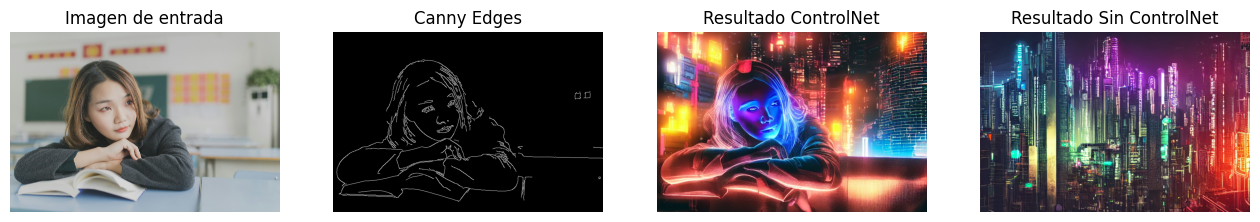

In [8]:
# Importar librerías
from diffusers import StableDiffusionControlNetPipeline, ControlNetModel
from controlnet_aux import CannyDetector
from PIL import Image
import numpy as np
import cv2
import torch
import matplotlib.pyplot as plt
import os

# Configurar el modelo de ControlNet + Stable Diffusion
controlnet = ControlNetModel.from_pretrained("lllyasviel/sd-controlnet-canny", torch_dtype=torch.float16)
pipe = StableDiffusionControlNetPipeline.from_pretrained(
    "runwayml/stable-diffusion-v1-5",
    controlnet=controlnet,
    torch_dtype=torch.float16
).to("cuda")

# Cargar y procesar imagen de entrada para Canny
def load_and_process_image(image_path):
    image = Image.open(image_path).convert("RGB")
    image_np = np.array(image)
    # Aplicar Canny edge detection
    detector = CannyDetector()
    condition_image = detector(image)
    return image, condition_image

# Generar imagen con y sin ControlNet
def generate_images(prompt, condition_image=None):
    # Generar con ControlNet (si se proporciona imagen de condición)
    if condition_image is not None:
        result_controlnet = pipe(
            prompt,
            image=condition_image,
            num_inference_steps=30,
            guidance_scale=7.5
        ).images[0]
    else:
        result_controlnet = None

    # Generar sin ControlNet (solo texto)
    result_no_control = pipe(
        prompt,
        image=condition_image, # Pass the condition_image but set scale to 0
        num_inference_steps=30,
        guidance_scale=7.5,
        controlnet_conditioning_scale=0.0 # Set conditioning scale to 0 for no controlnet effect
    ).images[0]


    return result_controlnet, result_no_control

# Ejemplo de uso
image_path = "imagen.jpg"
prompt = "A cyberpunk city skyline at night, neon lights, futuristic buildings"
input_image, condition_image = load_and_process_image(image_path)

# Create results directory if it doesn't exist
if not os.path.exists("resultados"):
    os.makedirs("resultados")

# Save Canny edges image
condition_image.save("resultados/canny_edges.png")


# Generar imágenes
result_controlnet, result_no_control = generate_images(prompt, condition_image)

# Guardar resultados
if result_controlnet:
    result_controlnet.save("resultados/resultado_controlnet.png")
if result_no_control:
    result_no_control.save("resultados/resultado_no_controlnet.png")

# Mostrar imágenes
plt.figure(figsize=(16, 6))

plt.subplot(1, 4, 1)
plt.title("Imagen de entrada")
plt.imshow(input_image)
plt.axis("off")

plt.subplot(1, 4, 2)
plt.title("Canny Edges")
plt.imshow(condition_image, cmap="gray")
plt.axis("off")

plt.subplot(1, 4, 3)
plt.title("Resultado ControlNet")
plt.imshow(result_controlnet)
plt.axis("off")

plt.subplot(1, 4, 4)
plt.title("Resultado Sin ControlNet")
plt.imshow(result_no_control)
plt.axis("off")

plt.show()